### Importações

In [1]:
import duckdb

### Conectar ao banco de dados

In [2]:

conn = duckdb.connect()

### Arquivos

In [7]:
data_0 = "data/raw/parquet/train/*0.parquet"
data_1 = "data/raw/parquet/train/*1.parquet"
#data_2 = "data/raw/parquet/train/*2.parquet"
#data_3 = "data/raw/parquet/train/*3.parquet"
all_data = "data/raw/parquet/train/*.parquet"

### Descrição da base
- Tipos das colunas
- Total de colunas


In [8]:
schema = conn.execute(f"""
DESCRIBE
SELECT DISTINCT(*)
FROM '{all_data}'; -- Pode ajustar ou não o caminho para um dos arquivos Parquet gerados
""").fetchdf()

print(schema)

     column_name column_type null   key default extra
0    customer_ID     VARCHAR  YES  None    None  None
1            S_2        DATE  YES  None    None  None
2            P_2      DOUBLE  YES  None    None  None
3           D_39      DOUBLE  YES  None    None  None
4            B_1      DOUBLE  YES  None    None  None
..           ...         ...  ...   ...     ...   ...
185        D_141      DOUBLE  YES  None    None  None
186        D_142      DOUBLE  YES  None    None  None
187        D_143      DOUBLE  YES  None    None  None
188        D_144      DOUBLE  YES  None    None  None
189        D_145      DOUBLE  YES  None    None  None

[190 rows x 6 columns]


In [10]:
for i in range(2):
    schema = conn.execute(f"""
    SELECT count(*)
    FROM 'data/raw/parquet/train/*{i}.parquet';
    """).fetchdf()
    print(f"Parquet {i}: {schema.iloc[0, 0]}")

Parquet 0: 2764296
Parquet 1: 2767155


#Counting total number of records.

In [ ]:
schema = conn.execute(f"""
    SELECT count(*)
    FROM '{all_data}';
    """).fetchdf() 
print(schema.iloc[0, 0])

5531451


In [3]:
schema = conn.execute(f"""
    SELECT count(*)
    FROM '../data/processed/temp_temporal.parquet';
    """).fetchdf() 
print(schema.iloc[0, 0])

5531451


In [ ]:
schema = conn.execute(f"""
    SELECT count(*)
    FROM '../data/processed/dataset_final.parquet';
    """).fetchdf() 
print(schema.iloc[0, 0])

458913


In [13]:
conn.execute("""
SELECT COUNT(DISTINCT customer_ID)
FROM 'data/raw/parquet/train/*.parquet';
""").fetchdf()

,count(DISTINCT customer_ID)
0,458913


In [ ]:
schema = conn.execute("""
DESCRIBE
SELECT *
FROM '../data/processed/dataset_final.parquet'
""").fetchdf()

print(schema)

                         column_name column_type null   key default extra
0                        customer_ID     VARCHAR  YES  None    None  None
1                           P_2_mean      DOUBLE  YES  None    None  None
2                            P_2_std      DOUBLE  YES  None    None  None
3                            P_2_min      DOUBLE  YES  None    None  None
4                            P_2_max      DOUBLE  YES  None    None  None
...                              ...         ...  ...   ...     ...   ...
3259  D_120_changed_change_frequency      DOUBLE  YES  None    None  None
3260  D_120_changed_changed_recently     INTEGER  YES  None    None  None
3261     D_126_changed_total_changes     INTEGER  YES  None    None  None
3262  D_126_changed_change_frequency      DOUBLE  YES  None    None  None
3263  D_126_changed_changed_recently     INTEGER  YES  None    None  None

[3264 rows x 6 columns]


In [8]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = conn.execute(f"SELECT * FROM '{data_0}' --LIMIT 10000").fetchdf()
# numeric_df = df.select_dtypes(include='number')

# fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# sns.heatmap(numeric_df.corr(method='pearson'), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
# axes[0].set_title('Correlação de Pearson')

# sns.heatmap(numeric_df.corr(method='spearman'), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
# axes[1].set_title('Correlação de Spearman')

# plt.tight_layout()
# plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = conn.execute(f"SELECT * FROM '{data_0}' --LIMIT 10000").fetchdf()
numeric_df = df.select_dtypes(include='number')

# Ajusta o tamanho da figura para bases com muitas features (até ocupar melhor a tela)
n_features = numeric_df.shape[1]
fig_size = max(30, min(70, n_features * 0.35))
plt.figure(figsize=(fig_size, fig_size), dpi=120)

sns.heatmap(
    numeric_df.corr(method='pearson'),
    annot=True,
    cmap='coolwarm',
    square=True,
    cbar_kws={'shrink': 0.8}
 )
plt.title('Correlação de Pearson')
plt.tight_layout()
plt.show()

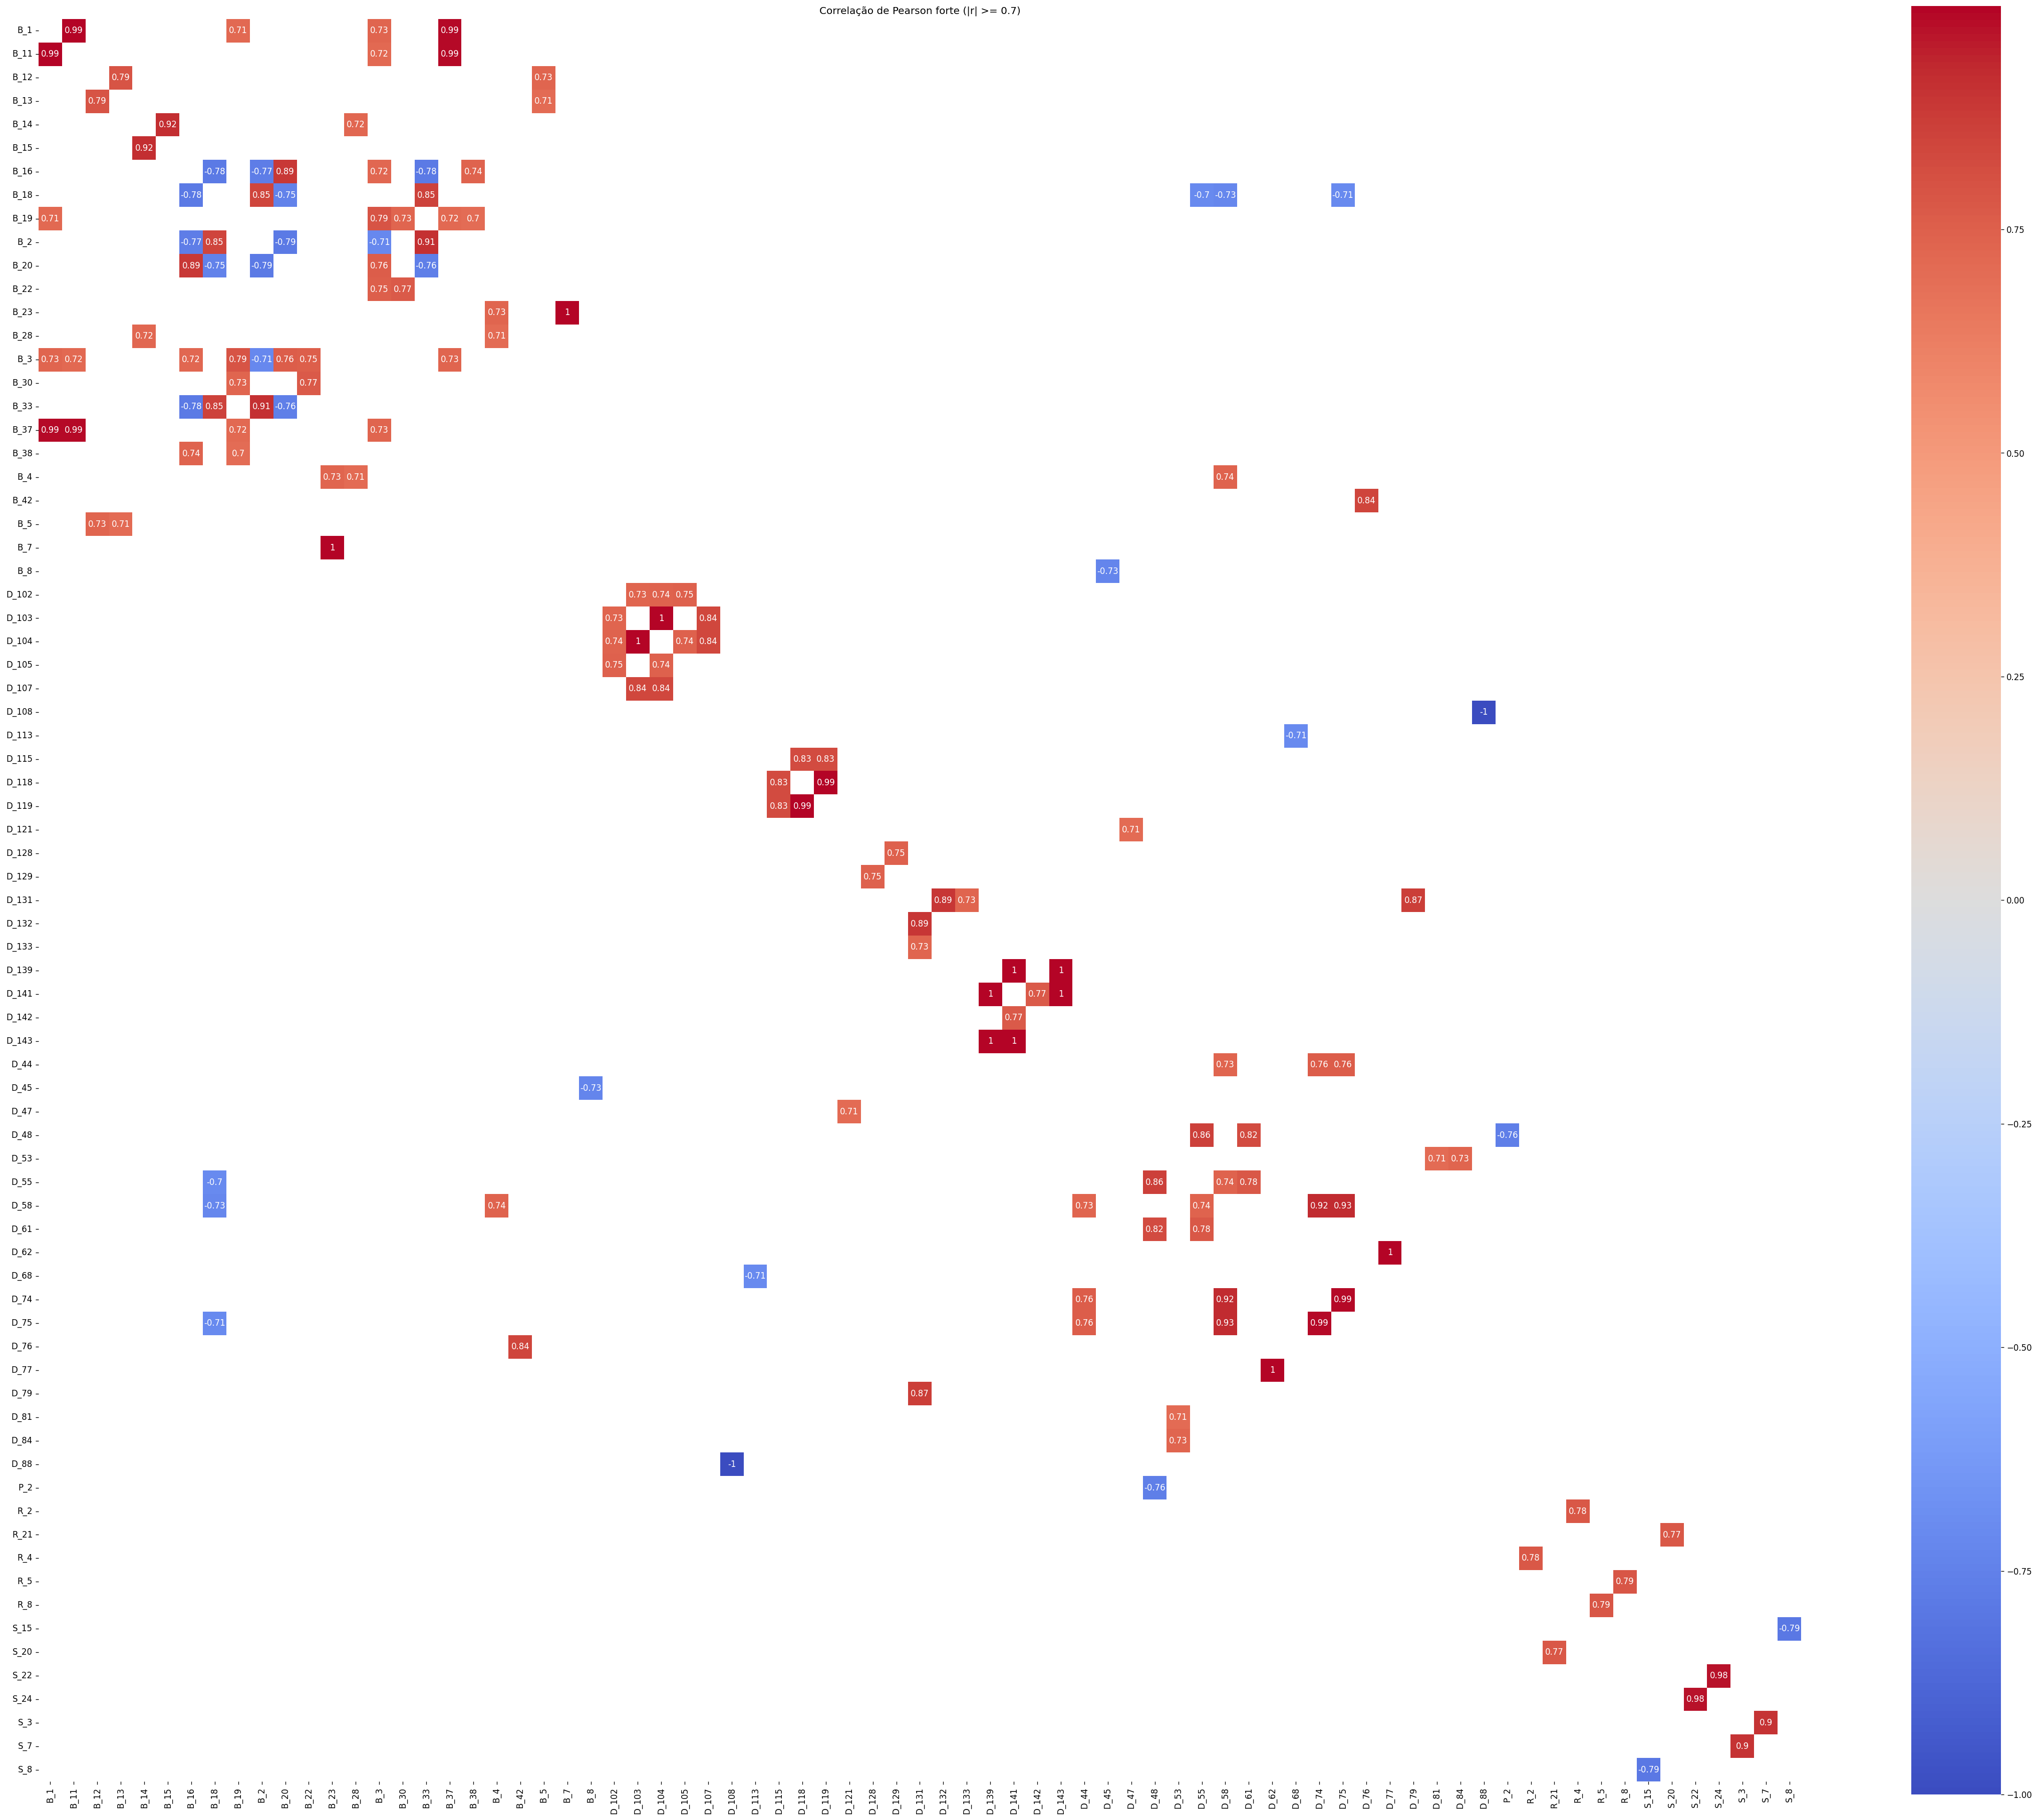

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = conn.execute(f"SELECT * FROM '{data_1}'").fetchdf()
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr(method='pearson')
threshold = 0.7  # ajuste aqui se quiser mais/menos rigor para "forte"

# Considera apenas metade superior para encontrar pares fortes sem duplicar
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = upper.abs() >= threshold

strong_features = sorted(
    set(upper.columns[strong_pairs.any(axis=0)]) |
    set(upper.index[strong_pairs.any(axis=1)])
)

if not strong_features:
    print(f"Nenhuma correlação forte encontrada com |r| >= {threshold}.")
else:
    strong_corr = corr.loc[strong_features, strong_features]

    # Mantém no gráfico apenas células com correlação forte e remove diagonal
    mask_weak = strong_corr.abs() < threshold
    diag_mask = pd.DataFrame(
        np.eye(len(strong_corr), dtype=bool),
        index=strong_corr.index,
        columns=strong_corr.columns
    )
    mask_weak = mask_weak | diag_mask

    n_features = len(strong_features)
    fig_size = max(16, min(60, n_features * 0.5))
    plt.figure(figsize=(fig_size, fig_size), dpi=120)

    sns.heatmap(
        strong_corr.mask(mask_weak),
        annot=True,
        cmap='coolwarm',
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f"Correlação de Pearson forte (|r| >= {threshold})")
    plt.tight_layout()
    plt.show()